# 第 19 章花卉分类
沿用第 17 章公开 Iris 快照。四特征主模型与两特征画图模型分开。

In [1]:
from examples.classification_core import experiment, predict_one_with_proba
from examples.project_core import FEATURES, TARGET_NAMES
model,boundary,train,test,summary=experiment()
print("全部/训练/测试",summary["all_class_counts"],summary["train_class_counts"],summary["test_class_counts"])

全部/训练/测试 [50, 50, 50] [40, 40, 40] [10, 10, 10]


In [2]:
p=model.predict_proba(test[FEATURES])
print("类别列顺序",model.classes_)
print(p[:3])
print("每行合计",p[:3].sum(axis=1))

类别列顺序 [0 1 2]
[[9.78818005e-01 2.11816311e-02 3.63821812e-07]
 [3.79836951e-03 3.69220168e-01 6.26981463e-01]
 [1.48799040e-01 8.42474895e-01 8.72606441e-03]]
每行合计 [1. 1. 1.]


In [3]:
print("测试正确",summary["test_correct"],"/",len(test))
print(summary["confusion_matrix"])

测试正确 28 / 30
[[10, 0, 0], [0, 9, 1], [0, 1, 9]]


In [4]:
print(test.loc[~test.correct,["sample_id","target","prediction","p_setosa","p_versicolor","p_virginica"]].to_string(index=False))

sample_id  target  prediction  p_setosa  p_versicolor  p_virginica
 iris-134       2           1  0.001290      0.514525     0.484185
 iris-077       1           2  0.001454      0.441685     0.556861


In [5]:
print(predict_one_with_proba(model,[5.1,3.5,1.4,.2]))
print("两特征测试准确率",summary["boundary_test_accuracy"])

{'label': 0, 'name': 'setosa', 'probabilities': {'setosa': 0.9808127381969151, 'versicolor': 0.019186992121988183, 'virginica': 2.696810968691848e-07}}
两特征测试准确率 0.9333333333333333


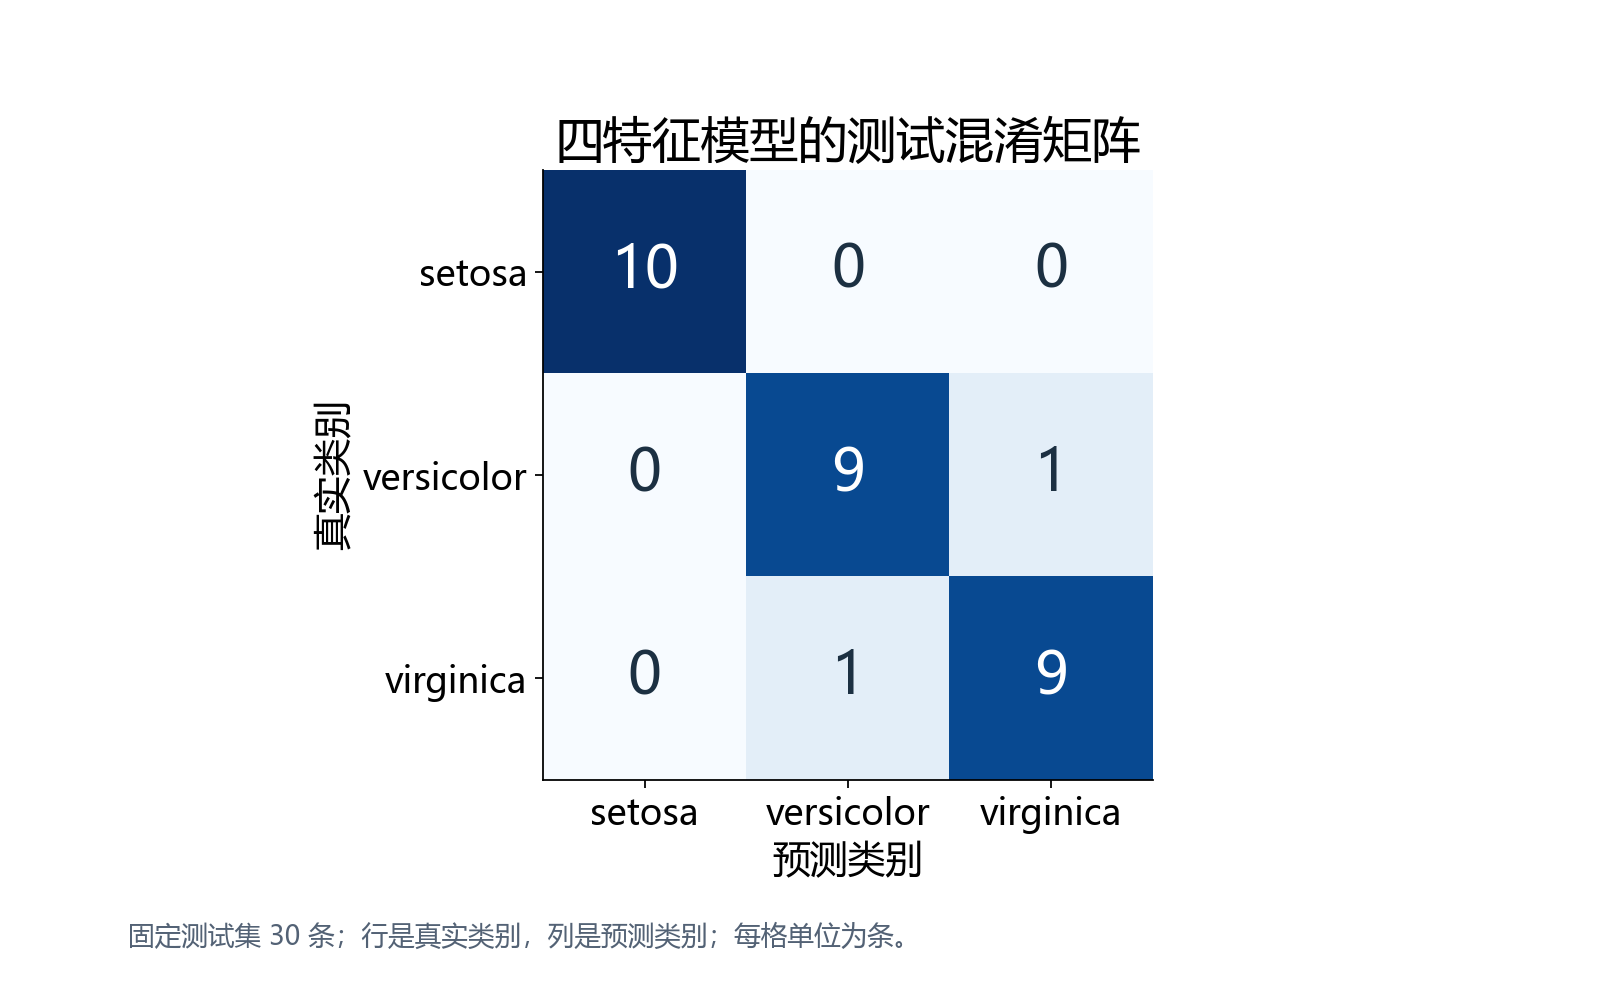

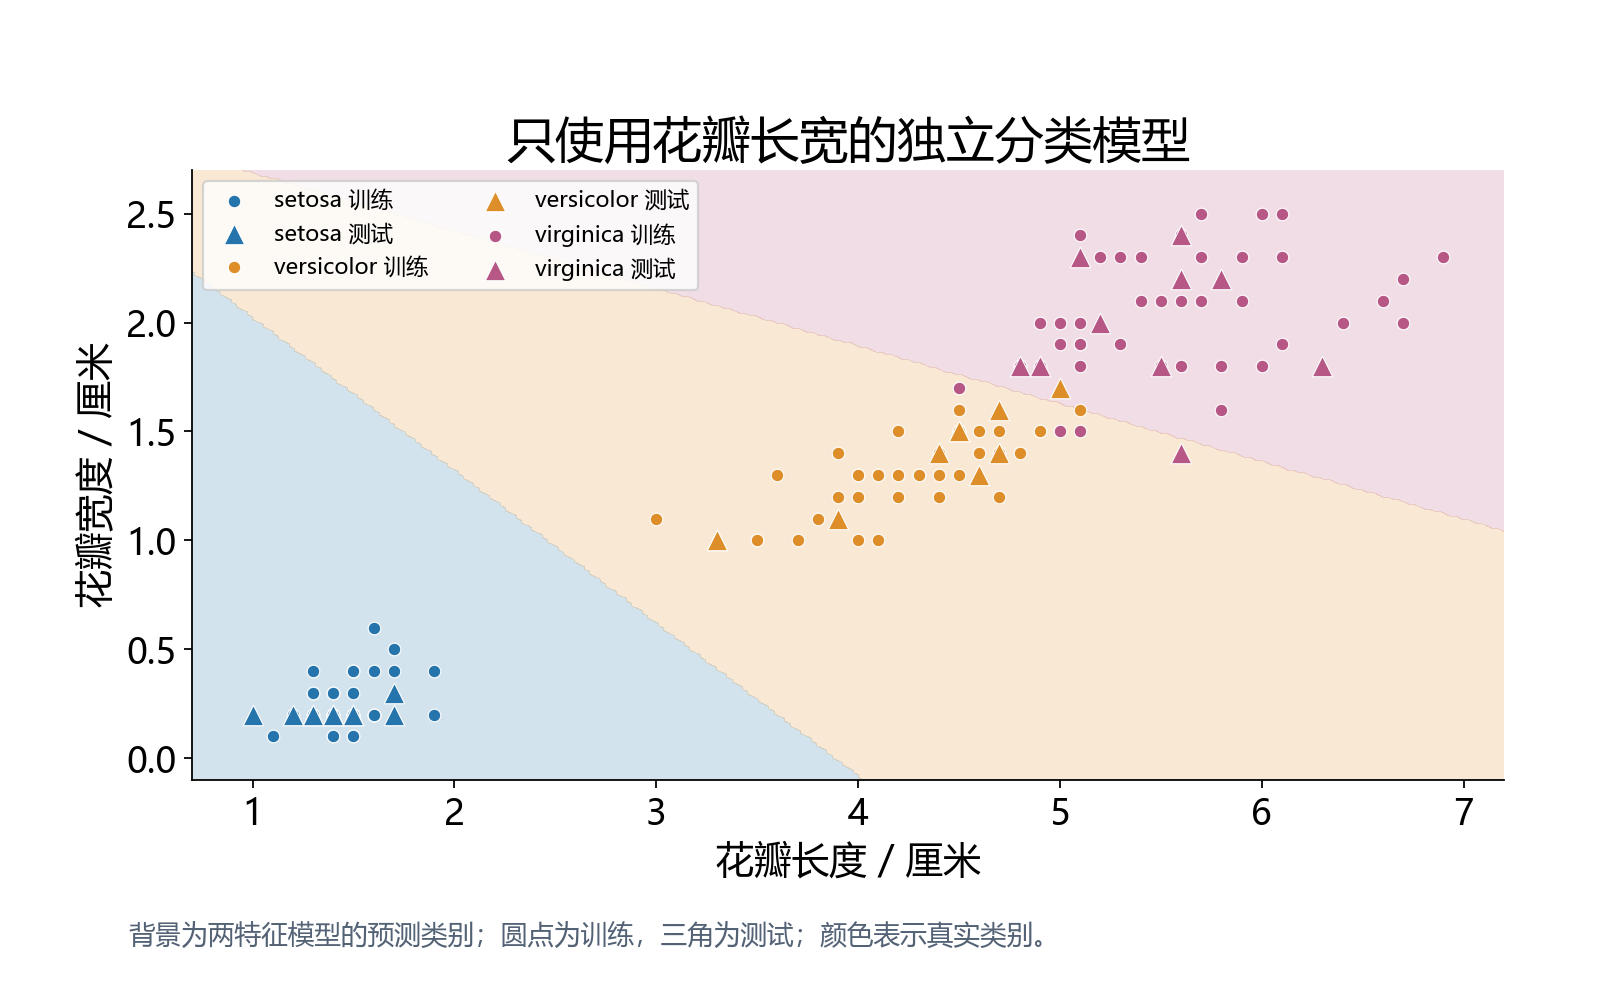

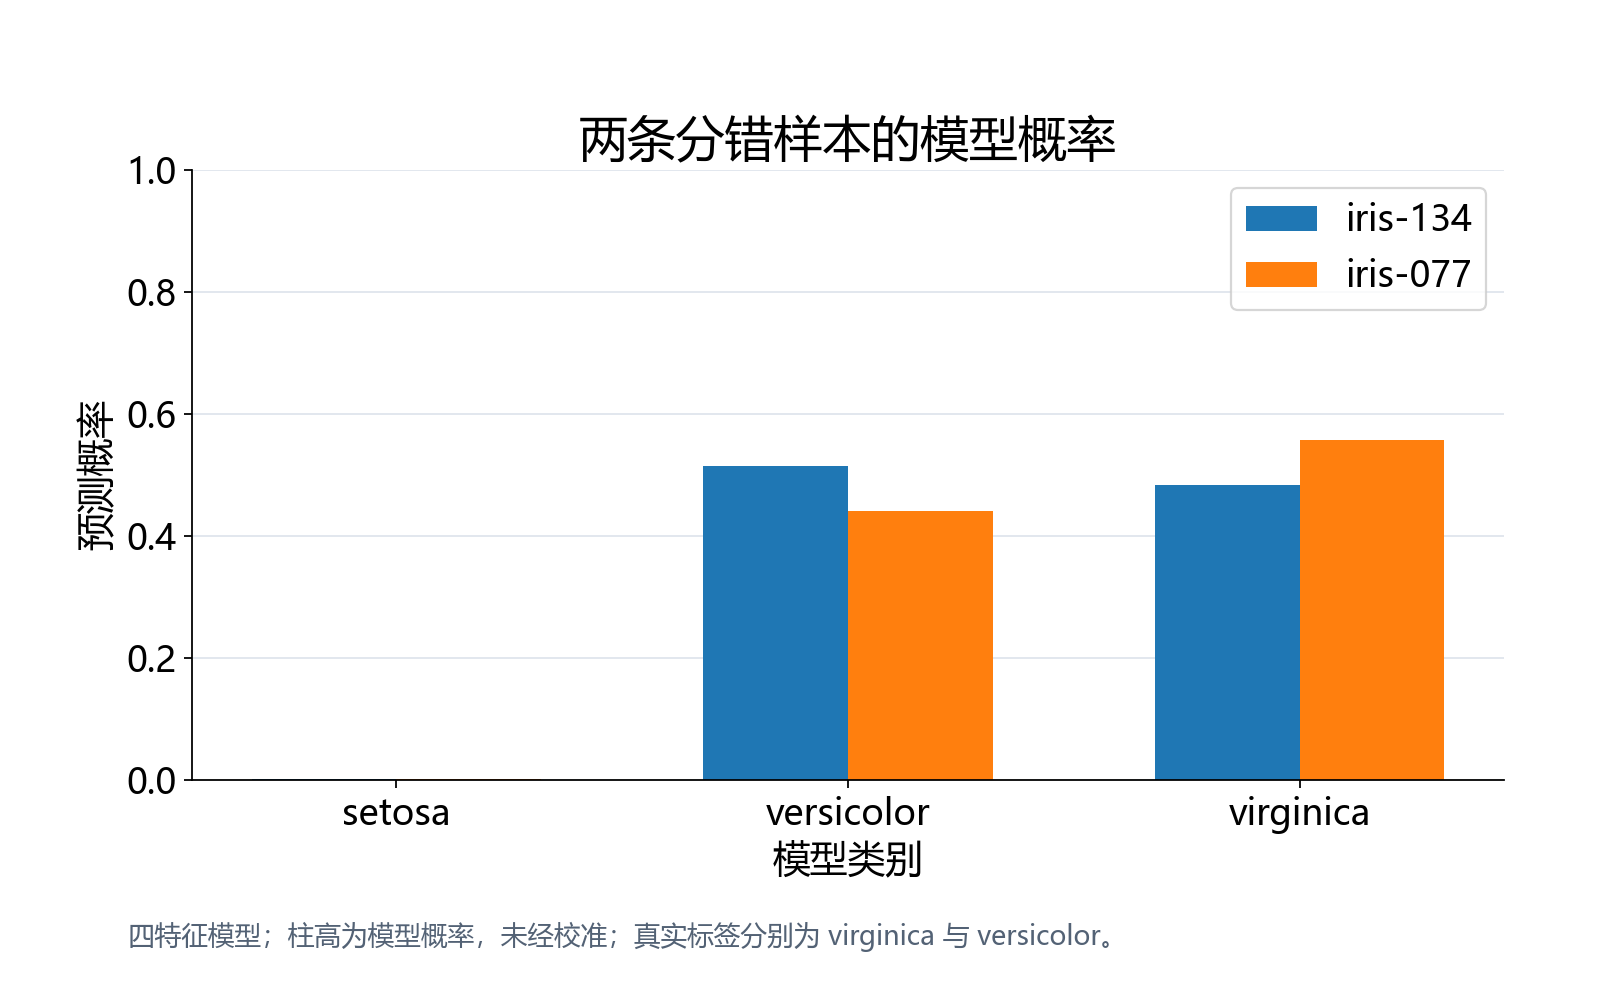

In [6]:
from IPython.display import display, Image
for name in ["confusion-matrix","decision-boundary","wrong-probabilities"]:
    display(Image(filename=f"assets/{name}.png",width=700))

In [7]:
import numpy as np
classes=np.array([2,0,1]); probabilities=np.array([.7,.2,.1])
print("练习类别",classes[probabilities.argmax()])
assert classes[probabilities.argmax()]==2

练习类别 2
